批量规范化（batch normalization）可持续加速深层网络的收敛速度

数据预处理的方式通常会对最终结果产生巨大影响。

对于典型的多层感知机或卷积神经网络。当我们训练时，中间层中的变量（例如，多层感知机中的仿射变换输出）可能具有更广的变化范围。
这些变量分布中的这种偏移可能会阻碍网络的收敛

更深层的网络很复杂，容易过拟合。

原理：在每次训练迭代中，我们首先规范化输入，即通过减去其均值并除以其标准差，其中两者均基于当前小批量处理。

优化中的各种噪声源通常会导致更快的训练和较少的过拟合

批量规范化层

全连接层和卷积层，他们的批量规范化实现略有不同。

全连接层：将批量规范化层置于全连接层中的仿射变换和激活函数之间。
$$\mathbf{h} = \phi(\mathrm{BN}(\mathbf{W}\mathbf{x} + \mathbf{b}) ).$$

卷积层：在卷积层之后和非线性激活函数之前应用批量规范化。假设我们的小批量包含 m 个样本，并且对于每个通道，卷积的输出具有高度 p 和宽度 q 。 那么对于卷积层，我们在每个输出通道的 m⋅p⋅q 个元素上同时执行每个批量规范化。

预测过程中的批量规范化

批量规范化在训练模式和预测模式下的行为通常不同。一种常用的方法是通过移动平均估算整个训练数据集的样本均值和方差，并在预测时使用它们得到确定的输出。



实现一个具有张量的批量规范化层

In [5]:
import torch
from torch import nn


def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # 通过is_grad_enabled来判断当前模式是训练模式还是预测模式
    if not torch.is_grad_enabled():
        # 如果是在预测模式下，直接使用传入的移动平均所得的均值和方差
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # 使用全连接层的情况，计算特征维上的均值和方差
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # 使用二维卷积层的情况，计算通道维上（axis=1）的均值和方差。
            # 这里我们需要保持X的形状以便后面可以做广播运算
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # 训练模式下，用当前的均值和方差做标准化
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # 更新移动平均的均值和方差
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta  # 缩放和移位
    return Y, moving_mean.data, moving_var.data

创建一个正确的BatchNorm层，这个层将保持适当的参数：拉伸gamma和偏移beta,这两个参数将在训练过程中更新。

将batch norm的功能集成到一个自定义层中，其代码主要处理数据移动到训练设备（如GPU）、分配和初始化任何必需的变量、跟踪移动平均线（此处为均值和方差）等问题。

In [6]:
class BatchNorm(nn.Module):
    # num_features：完全连接层的输出数量或卷积层的输出通道数。
    # num_dims：2表示完全连接层，4表示卷积层
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # 参与求梯度和迭代的拉伸和偏移参数，分别初始化成1和0
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # 非模型参数的变量初始化为0和1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # 如果X不在内存上，将moving_mean和moving_var
        # 复制到X所在显存上
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # 保存更新过的moving_mean和moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.9)
        return Y

使用批量规范化层的 LeNet



In [7]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), BatchNorm(6, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), BatchNorm(16, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(16*4*4, 120), BatchNorm(120, num_dims=2), nn.Sigmoid(),
    nn.Linear(120, 84), BatchNorm(84, num_dims=2), nn.Sigmoid(),
    nn.Linear(84, 10))

在Fashion-MNIST数据集上训练网络

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time

# 超参数
lr, num_epochs, batch_size = 1.0, 10, 256

# 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("training on", device)

# 数据加载
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 评估函数（替代 d2l 内置）
def evaluate_accuracy(net, data_iter, device):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += y.numel()
    return correct / total

# 训练函数（替代 d2l.train_ch6）
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        net.train()
        total_loss = 0
        total_correct = 0
        total_num = 0
        start = time.time()

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()

            total_loss += l.item() * X.shape[0]
            total_correct += (y_hat.argmax(dim=1) == y).sum().item()
            total_num += y.numel()

        train_loss = total_loss / total_num
        train_acc = total_correct / total_num
        test_acc = evaluate_accuracy(net, test_iter, device)

        print(f"epoch {epoch+1}, "
              f"train loss {train_loss:.4f}, "
              f"train acc {train_acc:.4f}, "
              f"test acc {test_acc:.4f}, "
              f"time {time.time() - start:.1f} sec")

# 开始训练
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 15.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 267kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.97MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.4MB/s]


epoch 1, train loss 0.8175, train acc 0.7023, test acc 0.7642, time 10.5 sec
epoch 2, train loss 0.5031, train acc 0.8145, test acc 0.7926, time 8.8 sec
epoch 3, train loss 0.4238, train acc 0.8456, test acc 0.7378, time 8.8 sec
epoch 4, train loss 0.4472, train acc 0.8364, test acc 0.7419, time 8.9 sec
epoch 5, train loss 0.3742, train acc 0.8623, test acc 0.5050, time 8.8 sec
epoch 6, train loss 0.3481, train acc 0.8713, test acc 0.8134, time 8.9 sec
epoch 7, train loss 0.3298, train acc 0.8777, test acc 0.7646, time 8.8 sec
epoch 8, train loss 0.3178, train acc 0.8821, test acc 0.6600, time 8.8 sec
epoch 9, train loss 0.3061, train acc 0.8863, test acc 0.8290, time 8.8 sec
epoch 10, train loss 0.2981, train acc 0.8899, test acc 0.6234, time 8.9 sec


从第一个批量规范化层中学到的拉伸参数gamma和偏移参数beta

In [8]:
net[1].gamma.reshape((-1,)), net[1].beta.reshape((-1,))

(tensor([1., 1., 1., 1., 1., 1.], grad_fn=<ViewBackward0>),
 tensor([0., 0., 0., 0., 0., 0.], grad_fn=<ViewBackward0>))

简洁实现

In [9]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10))

In [11]:
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.7972, train acc 0.7068, test acc 0.7558, time 8.3 sec
epoch 2, train loss 0.4875, train acc 0.8208, test acc 0.7685, time 8.1 sec
epoch 3, train loss 0.4149, train acc 0.8470, test acc 0.7241, time 8.1 sec
epoch 4, train loss 0.3710, train acc 0.8639, test acc 0.8200, time 8.1 sec
epoch 5, train loss 0.3436, train acc 0.8744, test acc 0.8597, time 8.1 sec
epoch 6, train loss 0.3263, train acc 0.8800, test acc 0.8329, time 8.1 sec
epoch 7, train loss 0.3059, train acc 0.8875, test acc 0.8523, time 8.1 sec
epoch 8, train loss 0.2970, train acc 0.8903, test acc 0.8382, time 8.1 sec
epoch 9, train loss 0.2849, train acc 0.8944, test acc 0.7967, time 8.1 sec
epoch 10, train loss 0.2765, train acc 0.8985, test acc 0.8058, time 8.1 sec


## 练习

1. 在使用批量规范化之前，我们是否可以从全连接层或卷积层中删除偏置参数？为什么？





在使用批量规范化时，可以从全连接层或卷积层中删除偏置参数。原因在于，Batch Normalization 会对每一层的输出进行标准化处理，即减去均值并除以标准差，这一过程会抵消掉原有层中的偏置项。此外，Batch Normalization 中还包含一个可学习的偏移参数 β，用于恢复数据分布的位置。

1. 比较LeNet在使用和不使用批量规范化情况下的学习率。
    1. 绘制训练和测试准确度的提高。
    1. 学习率有多高？

In [12]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time

batch_size = 256

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("training on", device)

training on cuda


定义LeNet

In [13]:
def get_lenet():
    net = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2),
        nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),

        nn.Conv2d(6, 16, kernel_size=5),
        nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),

        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120),
        nn.Sigmoid(),
        nn.Linear(120, 84),
        nn.Sigmoid(),
        nn.Linear(84, 10)
    )
    return net


def get_lenet_bn():
    net = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2, bias=False),
        nn.BatchNorm2d(6),
        nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),

        nn.Conv2d(6, 16, kernel_size=5, bias=False),
        nn.BatchNorm2d(16),
        nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),

        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120, bias=False),
        nn.BatchNorm1d(120),
        nn.Sigmoid(),

        nn.Linear(120, 84, bias=False),
        nn.BatchNorm1d(84),
        nn.Sigmoid(),

        nn.Linear(84, 10)
    )
    return net

初始化函数

In [14]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if getattr(m, "bias", None) is not None:
            nn.init.zeros_(m.bias)

评估函数

In [15]:
def evaluate_accuracy(net, data_iter, device):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += y.numel()
    return correct / total

训练函数

In [16]:
def train_model(net, train_iter, test_iter, num_epochs, lr, device):
    net.apply(init_weights)
    net.to(device)

    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    train_acc_list = []
    test_acc_list = []
    train_loss_list = []

    for epoch in range(num_epochs):
        net.train()
        total_loss = 0.0
        total_correct = 0
        total_num = 0
        start = time.time()

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = net(X)
            loss = loss_fn(y_hat, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X.shape[0]
            total_correct += (y_hat.argmax(dim=1) == y).sum().item()
            total_num += y.numel()

        train_loss = total_loss / total_num
        train_acc = total_correct / total_num
        test_acc = evaluate_accuracy(net, test_iter, device)

        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print(f"epoch {epoch+1}, "
              f"train loss {train_loss:.4f}, "
              f"train acc {train_acc:.4f}, "
              f"test acc {test_acc:.4f}, "
              f"time {time.time()-start:.1f} sec")

    return train_loss_list, train_acc_list, test_acc_list

比较在lr=1.0条件下，有无BN

In [17]:
num_epochs = 10
lr = 1.0

print("===== LeNet without BatchNorm =====")
net_plain = get_lenet()
plain_loss, plain_train_acc, plain_test_acc = train_model(
    net_plain, train_iter, test_iter, num_epochs, lr, device
)

print("\n===== LeNet with BatchNorm =====")
net_bn = get_lenet_bn()
bn_loss, bn_train_acc, bn_test_acc = train_model(
    net_bn, train_iter, test_iter, num_epochs, lr, device
)

===== LeNet without BatchNorm =====
epoch 1, train loss 2.3219, train acc 0.1012, test acc 0.1000, time 4.4 sec
epoch 2, train loss 2.3044, train acc 0.0998, test acc 0.1000, time 4.1 sec
epoch 3, train loss 2.3027, train acc 0.1041, test acc 0.1347, time 4.2 sec
epoch 4, train loss 1.5638, train acc 0.3838, test acc 0.5494, time 4.3 sec
epoch 5, train loss 0.8412, train acc 0.6661, test acc 0.6618, time 4.3 sec
epoch 6, train loss 0.6838, train acc 0.7299, test acc 0.7027, time 4.2 sec
epoch 7, train loss 0.6136, train acc 0.7617, test acc 0.7496, time 4.3 sec
epoch 8, train loss 0.5628, train acc 0.7839, test acc 0.7737, time 4.1 sec
epoch 9, train loss 0.5177, train acc 0.8024, test acc 0.7883, time 4.3 sec
epoch 10, train loss 0.4885, train acc 0.8162, test acc 0.8145, time 4.2 sec

===== LeNet with BatchNorm =====
epoch 1, train loss 0.6980, train acc 0.7536, test acc 0.6575, time 4.2 sec
epoch 2, train loss 0.4471, train acc 0.8383, test acc 0.7570, time 4.2 sec
epoch 3, train lo

画训练准确率和测试准确率曲线

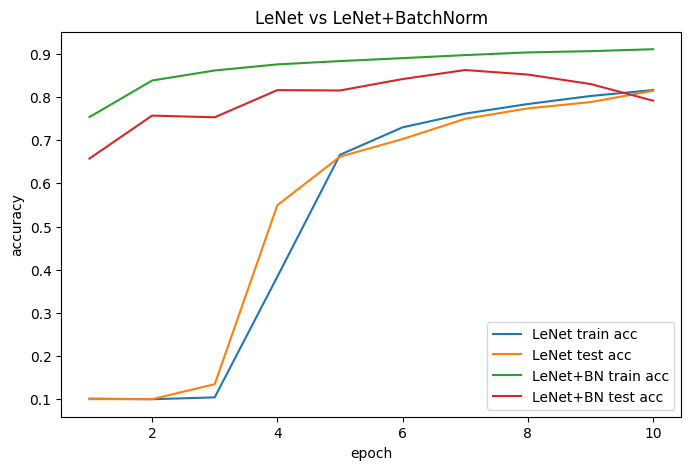

In [18]:
epochs = list(range(1, num_epochs + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, plain_train_acc, label="LeNet train acc")
plt.plot(epochs, plain_test_acc, label="LeNet test acc")
plt.plot(epochs, bn_train_acc, label="LeNet+BN train acc")
plt.plot(epochs, bn_test_acc, label="LeNet+BN test acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("LeNet vs LeNet+BatchNorm")
plt.legend()
plt.show()

结果表明，不使用 BatchNorm 时，网络对学习率较为敏感，当学习率较大时容易出现震荡甚至无法收敛；而加入 BatchNorm 后，网络训练更加稳定，能够使用更高的学习率，同时加快收敛速度。

加入 BatchNorm 的 LeNet 在前几个 epoch 中上升更快，说明其收敛速度更快；同时测试准确率通常也更高，说明 BatchNorm 有助于改善模型的泛化能力。

测试学习率

In [19]:
def try_learning_rates(model_fn, lr_list, train_iter, test_iter, num_epochs, device):
    results = {}
    for lr in lr_list:
        print(f"\n===== Testing lr={lr} =====")
        net = model_fn()
        _, train_acc, test_acc = train_model(net, train_iter, test_iter, num_epochs, lr, device)
        results[lr] = {
            "final_train_acc": train_acc[-1],
            "final_test_acc": test_acc[-1]
        }
    return results

比较不同学习率下的有无BN的LeNet

In [20]:
lr_list = [0.1, 0.5, 1.0, 2.0, 5.0]
num_epochs = 5

print("===== LeNet without BN: learning rate test =====")
plain_lr_results = try_learning_rates(get_lenet, lr_list, train_iter, test_iter, num_epochs, device)
print(plain_lr_results)

print("\n===== LeNet with BN: learning rate test =====")
bn_lr_results = try_learning_rates(get_lenet_bn, lr_list, train_iter, test_iter, num_epochs, device)
print(bn_lr_results)

===== LeNet without BN: learning rate test =====

===== Testing lr=0.1 =====
epoch 1, train loss 2.3065, train acc 0.1018, test acc 0.1000, time 4.1 sec
epoch 2, train loss 2.3053, train acc 0.0995, test acc 0.1000, time 4.4 sec
epoch 3, train loss 2.3045, train acc 0.1027, test acc 0.1000, time 4.2 sec
epoch 4, train loss 2.3043, train acc 0.1027, test acc 0.1000, time 4.4 sec
epoch 5, train loss 2.3038, train acc 0.1008, test acc 0.1000, time 4.1 sec

===== Testing lr=0.5 =====
epoch 1, train loss 2.3185, train acc 0.1010, test acc 0.1000, time 4.2 sec
epoch 2, train loss 1.5527, train acc 0.4197, test acc 0.5663, time 4.3 sec
epoch 3, train loss 0.9330, train acc 0.6314, test acc 0.6693, time 4.3 sec
epoch 4, train loss 0.7998, train acc 0.6919, test acc 0.6434, time 4.3 sec
epoch 5, train loss 0.7190, train acc 0.7219, test acc 0.6984, time 4.3 sec

===== Testing lr=1.0 =====
epoch 1, train loss 2.2249, train acc 0.1464, test acc 0.3748, time 4.2 sec
epoch 2, train loss 1.0368, tra

实验表明，加入 BatchNorm 后，LeNet 可以承受更高的学习率。普通 LeNet 通常在学习率较大时容易训练不稳定，而加入 BatchNorm 后，即使使用更大的学习率，模型仍能保持较平稳的训练过程。

1. 我们是否需要在每个层中进行批量规范化？尝试一下？

In [21]:
def get_lenet_all_bn():
    return nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2, bias=False),
        nn.BatchNorm2d(6),
        nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),

        nn.Conv2d(6, 16, kernel_size=5, bias=False),
        nn.BatchNorm2d(16),
        nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),

        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120, bias=False),
        nn.BatchNorm1d(120),
        nn.Sigmoid(),

        nn.Linear(120, 84, bias=False),
        nn.BatchNorm1d(84),
        nn.Sigmoid(),

        nn.Linear(84, 10)
    )

net = get_lenet_all_bn()

lr, num_epochs, batch_size = 1.0, 10, 256
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.7482, train acc 0.7306, test acc 0.6892, time 4.1 sec
epoch 2, train loss 0.4558, train acc 0.8351, test acc 0.7495, time 4.1 sec
epoch 3, train loss 0.3766, train acc 0.8632, test acc 0.6464, time 4.2 sec
epoch 4, train loss 0.3349, train acc 0.8780, test acc 0.8096, time 4.2 sec
epoch 5, train loss 0.3080, train acc 0.8879, test acc 0.8042, time 4.1 sec
epoch 6, train loss 0.2864, train acc 0.8951, test acc 0.8264, time 4.3 sec
epoch 7, train loss 0.2713, train acc 0.9002, test acc 0.8747, time 4.2 sec
epoch 8, train loss 0.2619, train acc 0.9053, test acc 0.8087, time 4.2 sec
epoch 9, train loss 0.2506, train acc 0.9079, test acc 0.8312, time 4.2 sec
epoch 10, train loss 0.2395, train acc 0.9114, test acc 0.8586, time 4.2 sec


不一定需要在每个层中都进行批量规范化。实验中可以发现，在卷积层和主要全连接层后加入BatchNorm往往就能显著改善训练稳定性和收敛速度，而将加到几乎每一层后，虽然也能训练，但效果不一定更明显还会增加额外计算开销。

1. 可以通过批量规范化来替换暂退法吗？行为会如何改变？

In [22]:
def get_mlp_bn():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 256, bias=False),
        nn.BatchNorm1d(256),
        nn.ReLU(),

        nn.Linear(256, 256, bias=False),
        nn.BatchNorm1d(256),
        nn.ReLU(),

        nn.Linear(256, 10)
    )

net = get_mlp_bn()

lr, num_epochs, batch_size = 1.0, 10, 256
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.5985, train acc 0.8038, test acc 0.8222, time 4.4 sec
epoch 2, train loss 0.3566, train acc 0.8676, test acc 0.8106, time 4.3 sec
epoch 3, train loss 0.3120, train acc 0.8839, test acc 0.8579, time 4.2 sec
epoch 4, train loss 0.2857, train acc 0.8925, test acc 0.8126, time 4.3 sec
epoch 5, train loss 0.2604, train acc 0.9018, test acc 0.8097, time 4.1 sec
epoch 6, train loss 0.2436, train acc 0.9073, test acc 0.8403, time 4.1 sec
epoch 7, train loss 0.2259, train acc 0.9156, test acc 0.8495, time 4.1 sec
epoch 8, train loss 0.2151, train acc 0.9187, test acc 0.8300, time 4.1 sec
epoch 9, train loss 0.2012, train acc 0.9234, test acc 0.8782, time 4.1 sec
epoch 10, train loss 0.1891, train acc 0.9293, test acc 0.8126, time 4.2 sec


用 BatchNorm 替代 Dropout 后，模型训练更快、收敛更稳定，但在某些情况下测试集上的泛化能力可能不如使用 Dropout 时那么强。

说明 BatchNorm 虽然也有一定正则化效果，但它并不能完全等价于 Dropout。

1. 确定参数`beta`和`gamma`，并观察和分析结果。

In [23]:
def get_lenet_fixed_bn(gamma=1.0, beta=0.0):
    net = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2, bias=False),
        nn.BatchNorm2d(6),
        nn.Sigmoid(),
        nn.AvgPool2d(2, 2),

        nn.Conv2d(6, 16, kernel_size=5, bias=False),
        nn.BatchNorm2d(16),
        nn.Sigmoid(),
        nn.AvgPool2d(2, 2),

        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120, bias=False),
        nn.BatchNorm1d(120),
        nn.Sigmoid(),

        nn.Linear(120, 84, bias=False),
        nn.BatchNorm1d(84),
        nn.Sigmoid(),

        nn.Linear(84, 10)
    )

    # 🔥 固定 gamma 和 beta
    for layer in net:
        if isinstance(layer, nn.BatchNorm2d) or isinstance(layer, nn.BatchNorm1d):
            layer.weight.data.fill_(gamma)
            layer.bias.data.fill_(beta)
            layer.weight.requires_grad = False
            layer.bias.requires_grad = False

    return net

In [24]:
net = get_lenet_fixed_bn(gamma=1.0, beta=0.0)

lr, num_epochs, batch_size = 1.0, 10, 256
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.8047, train acc 0.7137, test acc 0.7700, time 4.2 sec
epoch 2, train loss 0.5125, train acc 0.8171, test acc 0.7802, time 4.3 sec
epoch 3, train loss 0.4517, train acc 0.8390, test acc 0.8219, time 4.4 sec
epoch 4, train loss 0.4175, train acc 0.8515, test acc 0.8322, time 4.2 sec
epoch 5, train loss 0.3989, train acc 0.8576, test acc 0.8277, time 4.3 sec
epoch 6, train loss 0.3856, train acc 0.8607, test acc 0.8126, time 4.2 sec
epoch 7, train loss 0.3654, train acc 0.8686, test acc 0.8303, time 4.2 sec
epoch 8, train loss 0.3534, train acc 0.8724, test acc 0.8288, time 4.5 sec
epoch 9, train loss 0.3432, train acc 0.8752, test acc 0.7906, time 4.3 sec
epoch 10, train loss 0.3345, train acc 0.8785, test acc 0.8205, time 4.2 sec


当将 γ=1，β=0 时，BatchNorm 仅执行标准化操作，而不进行缩放和平移。此时模型仍然可以训练，但相比 γ 和 β 可学习的情况，收敛速度较慢，最终准确率也略低。

In [25]:
net_scaled = get_lenet_fixed_bn(gamma=0.5, beta=1.0)
train_model(net_scaled, train_iter, test_iter, 10, 1.0, device)

epoch 1, train loss 2.9379, train acc 0.5221, test acc 0.5704, time 4.2 sec
epoch 2, train loss 0.9435, train acc 0.7498, test acc 0.7557, time 4.1 sec
epoch 3, train loss 0.6535, train acc 0.8028, test acc 0.6062, time 4.2 sec
epoch 4, train loss 0.5814, train acc 0.8183, test acc 0.7389, time 4.2 sec
epoch 5, train loss 0.5104, train acc 0.8349, test acc 0.6767, time 4.7 sec
epoch 6, train loss 0.4730, train acc 0.8419, test acc 0.5030, time 4.6 sec
epoch 7, train loss 0.4470, train acc 0.8505, test acc 0.2180, time 4.2 sec
epoch 8, train loss 0.4363, train acc 0.8537, test acc 0.3841, time 4.1 sec
epoch 9, train loss 0.4116, train acc 0.8591, test acc 0.7085, time 4.2 sec
epoch 10, train loss 0.4083, train acc 0.8599, test acc 0.6242, time 4.2 sec


([2.9378517916361493,
  0.9434832561175028,
  0.6535474055926005,
  0.581362474568685,
  0.5103584573109945,
  0.47304938589731854,
  0.44704608114560446,
  0.43632710717519124,
  0.4116021867275238,
  0.4082636895020803],
 [0.5221333333333333,
  0.7497833333333334,
  0.8027666666666666,
  0.8182833333333334,
  0.8348833333333333,
  0.84195,
  0.8504833333333334,
  0.8537166666666667,
  0.8590666666666666,
  0.8598666666666667],
 [0.5704,
  0.7557,
  0.6062,
  0.7389,
  0.6767,
  0.503,
  0.218,
  0.3841,
  0.7085,
  0.6242])

当进一步改变 γ 和 β 的取值（γ=0.5 或 β=1）时，可以观察到模型输出分布发生变化，训练效果受到影响。

这说明 γ 和 β 的可学习性能够提高模型表达能力。γ 和 β 在 BatchNorm 中起着重要作用，它们能够在标准化之后恢复网络的表示能力，提高模型性能。